In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import glob
from scipy.interpolate import interp1d
import re
from scipy.optimize import curve_fit
import datetime


In [3]:
from RaTag.gamma_spectra.hidex_read import extract_hidex_raw_data

In [6]:
file1 = '/Users/pabloherrero/sabat/RaTagging/scope_data/hidex_data/HidexAMG-Pablo_measurement_2-001-20260208-180513.xlsx'

df0 = extract_hidex_raw_data(file1)

In [8]:
print(df0.head())

  ColA                    Datetime ParamC ParamD                      ParamE  \
0    5  2026-02-08 18:29:35.820000    001      6  2021-12-21 14:49:03.356000   
1    6  2026-02-08 18:35:39.502000    001      6  2021-12-21 14:49:03.356000   
2    7  2026-02-08 18:41:43.974000    001      6  2021-12-21 14:49:03.356000   
3    8  2026-02-08 18:47:48.637000    001      6  2021-12-21 14:49:03.356000   
4    9  2026-02-08 18:53:52.462000    001      6  2021-12-21 14:49:03.356000   

                                            Spectrum  
0  [1.0, 2.0, 2.0, 3.0, 2.0, 2.0, 1.0, 0.0, 3.0, ...  
1  [1.0, 2.0, 2.0, 1.0, 5.0, 1.0, 3.0, 3.0, 2.0, ...  
2  [2.0, 3.0, 5.0, 4.0, 5.0, 2.0, 2.0, 3.0, 3.0, ...  
3  [0.0, 2.0, 1.0, 4.0, 3.0, 5.0, 4.0, 4.0, 2.0, ...  
4  [1.0, 1.0, 2.0, 2.0, 5.0, 3.0, 3.0, 0.0, 2.0, ...  


In [33]:
df0.tail()

,ColA,Datetime,ParamC,ParamD,ParamE,Spectrum
1377,1382,2026-02-15 14:45:02.068000,001,6,2021-12-21 14:49:03.356000,"[3.0, 3.0, 4.0, 4.0, 7.0, 2.0, 4.0, 1.0, 0.0, ..."
1378,1383,2026-02-15 14:51:07.041000,001,6,2021-12-21 14:49:03.356000,"[1.0, 0.0, 1.0, 2.0, 2.0, 4.0, 3.0, 1.0, 1.0, ..."
1379,1384,2026-02-15 14:57:11.838000,001,6,2021-12-21 14:49:03.356000,"[0.0, 1.0, 2.0, 10.0, 4.0, 5.0, 1.0, 1.0, 4.0,..."
1380,1385,2026-02-15 15:03:16.421000,001,6,2021-12-21 14:49:03.356000,"[1.0, 0.0, 0.0, 6.0, 5.0, 2.0, 1.0, 1.0, 2.0, ..."
1381,1386,2026-02-15 15:09:20.625000,001,6,2021-12-21 14:49:03.356000,"[3.0, 0.0, 3.0, 4.0, 6.0, 4.0, 2.0, 2.0, 2.0, ..."


In [43]:
t_0_acc = datetime.datetime(2026, 2, 8, 18, 18, 0)
t_f_acc = datetime.datetime(2026, 2, 17, 21, 15, 0)
acc_seconds = (t_f_acc - t_0_acc).total_seconds()
print(f"Accumulation time in seconds: {acc_seconds:.0f} seconds")

t_0_meas = datetime.datetime(2026, 2, 17, 23, 43, 0)
delay_seconds = (t_0_meas - t_f_acc).total_seconds()
print(f"Delay time in seconds: {delay_seconds:.0f} seconds")

Accumulation time in seconds: 788220 seconds
Delay time in seconds: 8880 seconds


In [6]:

def gaussian_linear(x, a, mu, sigma, b, c):
    """Gaussian peak on a linear background."""
    return a * np.exp(-(x - mu) ** 2 / (2 * sigma ** 2)) + b * x + c


def analyze_hidex_folder(folder_path: str) -> pd.DataFrame:
    """
    Translate of Hidex_Analysis.m:
    For each HidexAMG AutoExport .xlsx in folder_path:
      - Read vial metadata from the 'Results' sheet (rows 27-37, cols A-E).
      - Read the corresponding spectrum row from the 'Spectra' sheet.
      - Fit a Gaussian + linear background and store parameters.
      - Save per-file results to <name>_Analysis.xlsx next to the source file.

    Returns
    -------
    pd.DataFrame
        Concatenated results for all files and all vials.
    """
    folder = Path(folder_path)
    files = sorted(folder.glob("HidexAMG-*.xlsx"))

    if not files:
        raise FileNotFoundError(f"No matching files found in {folder_path}")

    all_results = []

    for filepath in files:
        print(f"Processing: {filepath.name}")

        # --- Results sheet: rows 27-37 (Excel), cols A-E ---
        # skiprows=26 skips the first 26 rows (0-indexed); nrows=11 reads rows 27-37
        results_df = pd.read_excel(
            filepath,
            sheet_name="Results",
            usecols="A:E",
            skiprows=26,
            nrows=11,
            header=None,
            engine="openpyxl",
        )
        results_df.columns = ["ColA", "VialNumber", "ParamC", "ParamD", "ParamE"]

        # Valid rows: non-empty in column A (1-based index i+1, like MATLAB validRows)
        valid_mask = results_df["ColA"].notna()

        file_results = []

        for i, row_data in results_df[valid_mask].iterrows():
            # Align with Spectra sheet: MATLAB does row = validRows(idx) + 19
            # validRows(idx) is 1-based, i is 0-based → (i+1) + 19 = i + 20
            spectra_row_excel = i + 20  # 1-based Excel row in Spectra sheet

            # Read that single row from the Spectra sheet.
            # Columns C (idx 2) through BZV (idx 2049) → 2048 channels (0–2047).
            spectra_raw = pd.read_excel(
                filepath,
                sheet_name="Spectra",
                skiprows=spectra_row_excel - 1,  # 0-indexed: skip rows above
                nrows=1,
                header=None,
                engine="openpyxl",
            )
            # Keep only columns C:BZV (0-based: 2 to 2049)
            spectra_values = spectra_raw.iloc[0, 2:2050].values.astype(float)

            if np.any(np.isnan(spectra_values)):
                print(f"  Skipping spectra row {spectra_row_excel} — NaN values found.")
                continue

            x = np.arange(len(spectra_values), dtype=float)
            y = spectra_values

            # --- Gaussian + linear fit ---
            p0 = [float(np.max(y)), 220.0, 15.0, 0.0, float(np.min(y))]
            try:
                popt, _ = curve_fit(gaussian_linear, x, y, p0=p0, maxfev=10_000)
                a, mu, sigma, b, c = popt
                # R² (goodness-of-fit)
                residuals = y - gaussian_linear(x, *popt)
                ss_res = np.sum(residuals ** 2)
                ss_tot = np.sum((y - np.mean(y)) ** 2)
                r_sq = 1.0 - ss_res / ss_tot if ss_tot != 0 else 0.0
            except RuntimeError:
                a, mu, sigma, b, c = 0.0, 0.0, 0.0, 0.0, 0.0
                r_sq = 0.0

            file_results.append(
                {
                    "ExcelRow": spectra_row_excel,
                    "VialNumber": row_data["VialNumber"],
                    "ParamC": row_data["ParamC"],
                    "ParamD": row_data["ParamD"],
                    "ParamE": row_data["ParamE"],
                    "A": a,
                    "Mu": mu,
                    "Sigma": sigma,
                    "B": b,
                    "C": c,
                    "R_Square": r_sq,
                }
            )

            # --- Plot ---
            fig, ax = plt.subplots(figsize=(8, 4))
            ax.plot(x, y, "o", ms=3, label="Data")
            if a != 0:
                ax.plot(x, gaussian_linear(x, a, mu, sigma, b, c), label="Fitted Curve")
                ax.legend()
            ax.set_xlabel("Channel (0–2047)")
            ax.set_ylabel("Counts")
            ax.set_title(f"Vial {row_data['VialNumber']}  (Spectra row {spectra_row_excel})")
            ax.grid(True)
            plt.tight_layout()
            plt.show()

        if not file_results:
            continue

        results_table = pd.DataFrame(file_results)
        all_results.append(results_table)

        # --- Save per-file results ---
        # Strip "HidexAMG-" prefix and extract the *_*_V\d+-\d+ portion
        stem = filepath.stem
        clean_name = re.sub(r"^HidexAMG-", "", stem)
        match = re.search(r".*_.*_V\d+-\d+", clean_name)
        result_stem = match.group(0) if match else "Results"
        output_path = filepath.with_name(result_stem + "_Analysis.xlsx")
        results_table.to_excel(output_path, sheet_name="Analysis", index=False)
        print(f"  Results saved to: {output_path}")

    return pd.concat(all_results, ignore_index=True) if all_results else pd.DataFrame()


Processing: HidexAMG-Pablo_measurement-001-20260203-153747.xlsx


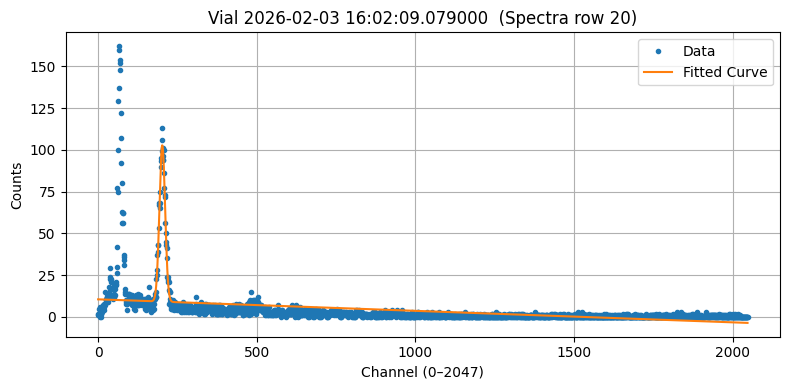

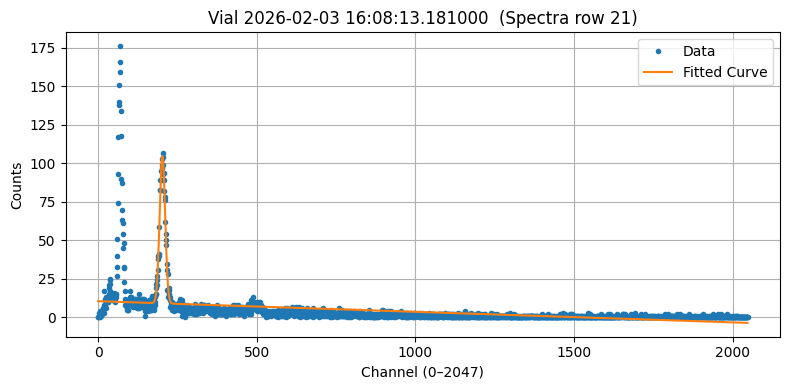

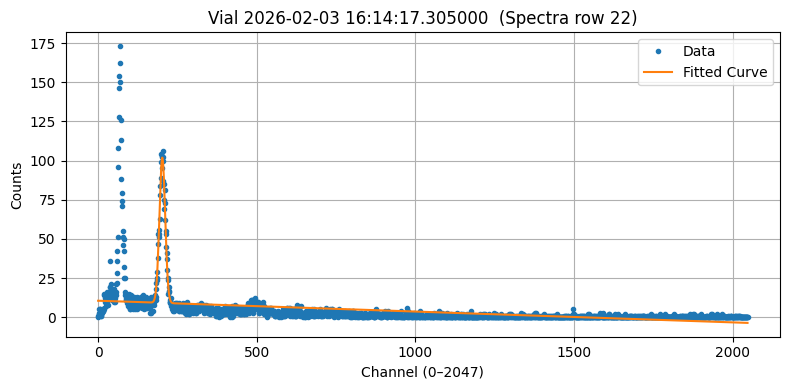

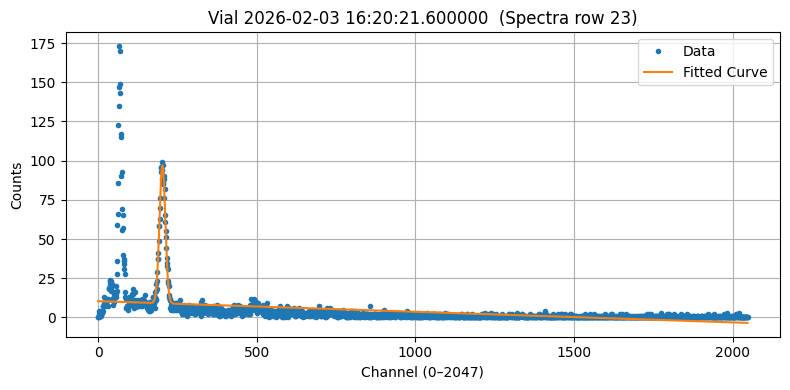

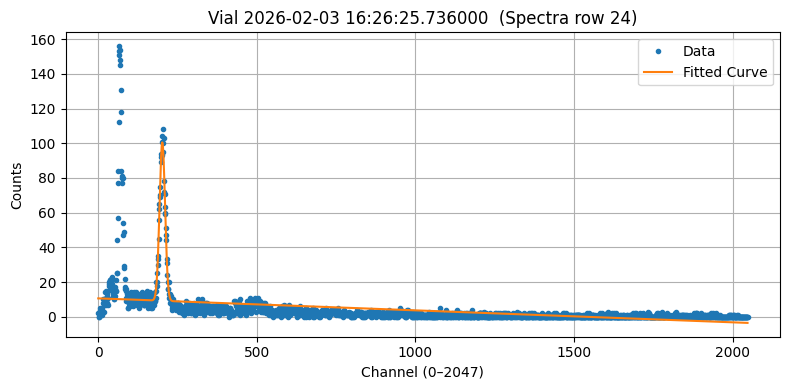

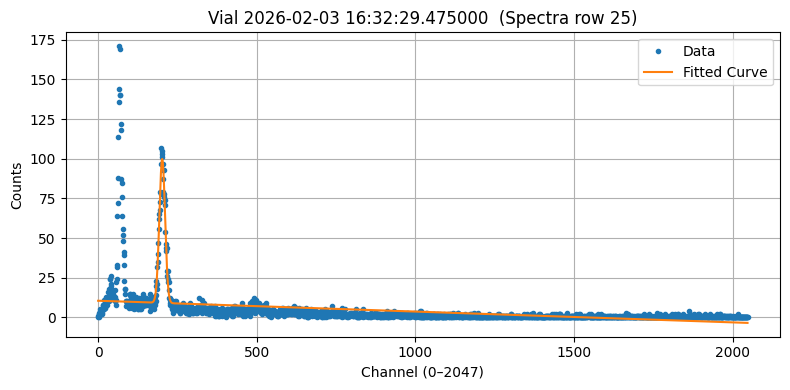

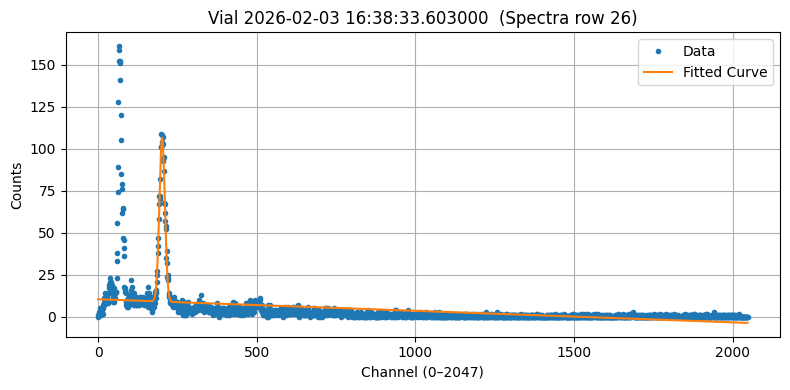

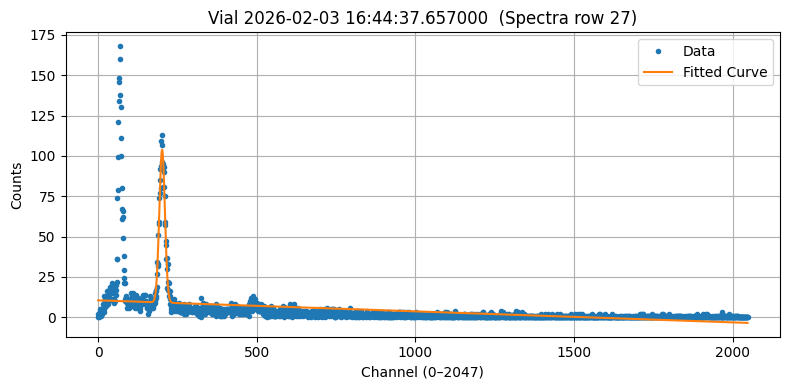

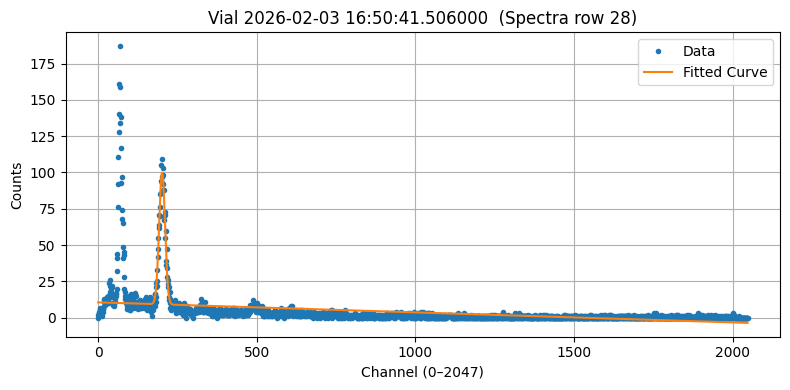

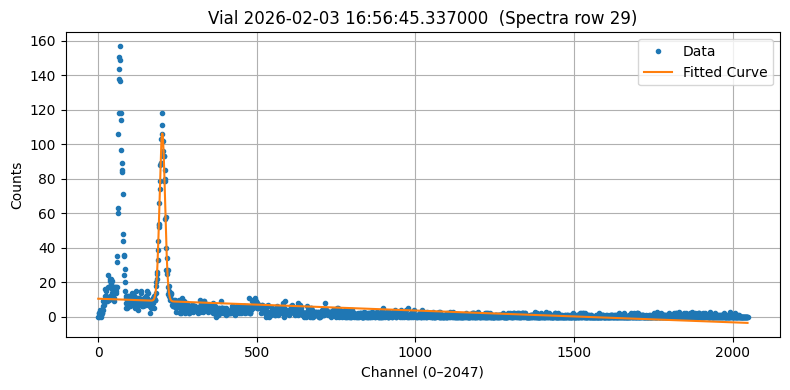

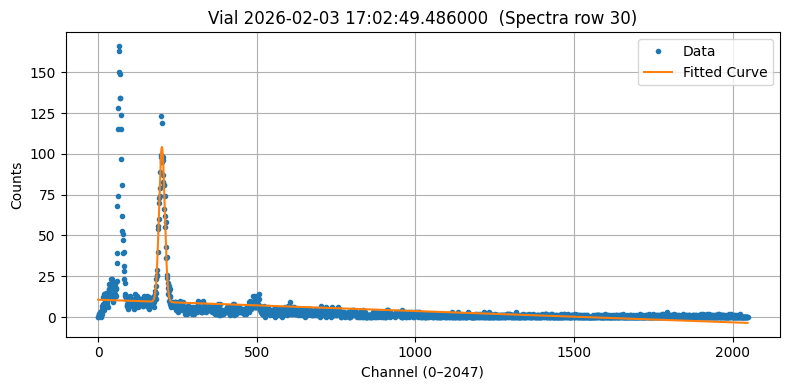

  Results saved to: /Users/pabloherrero/sabat/RaTagging/scope_data/hidex_data/Results_Analysis.xlsx
Processing: HidexAMG-Pablo_measurement_2-001-20260208-180513.xlsx


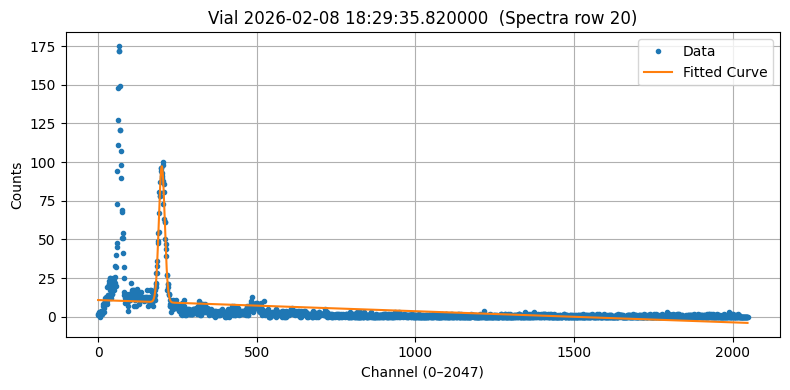

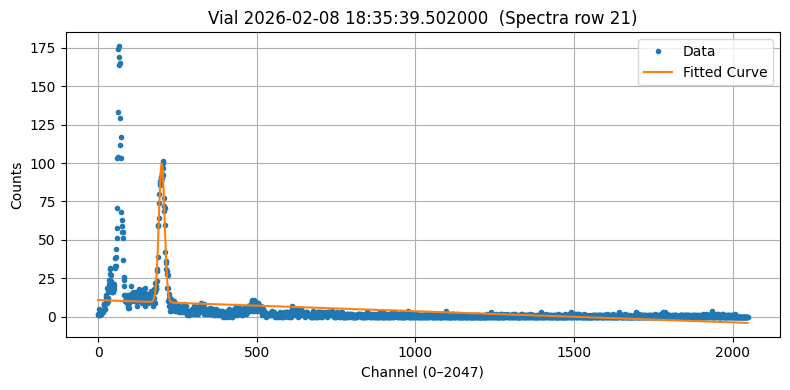

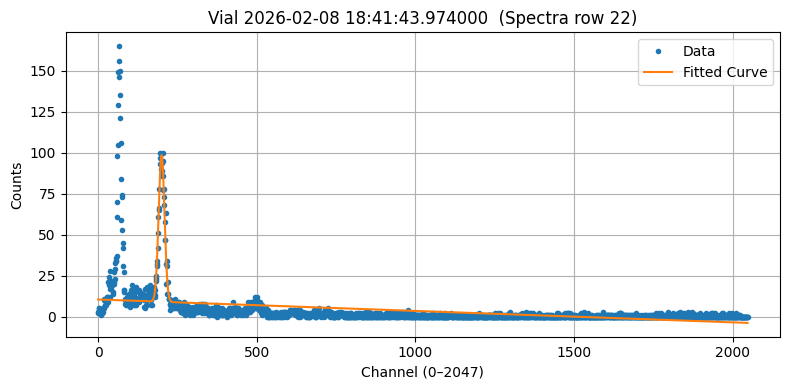

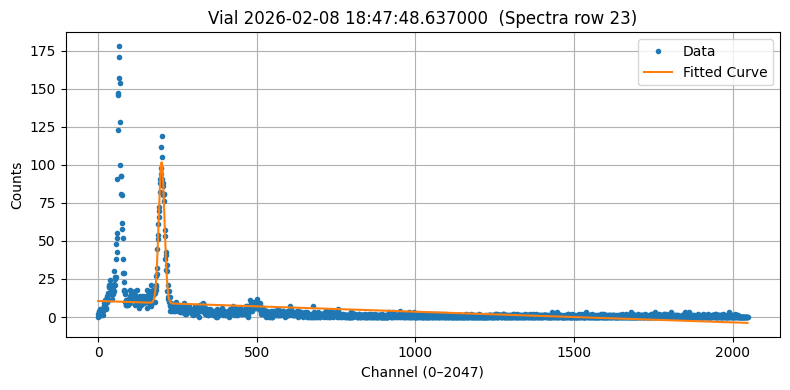

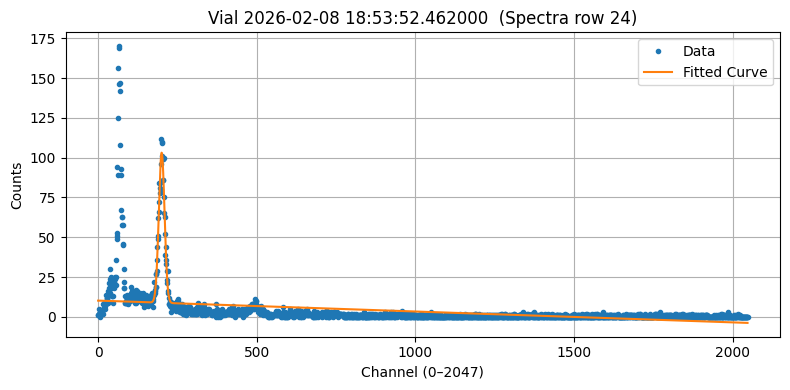

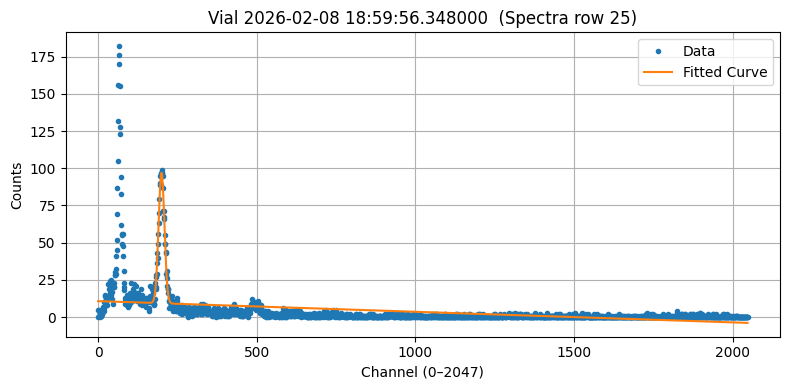

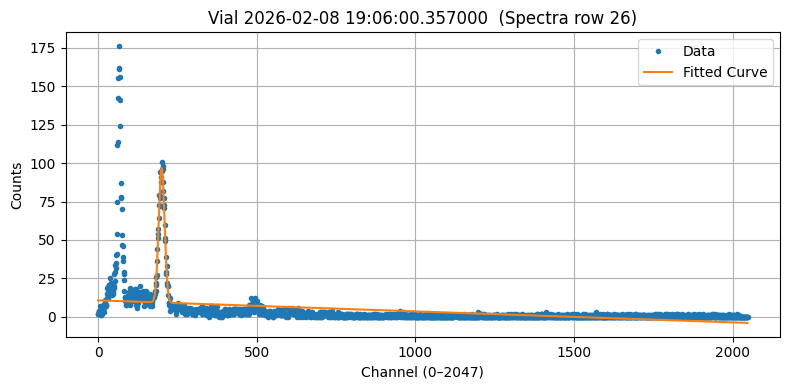

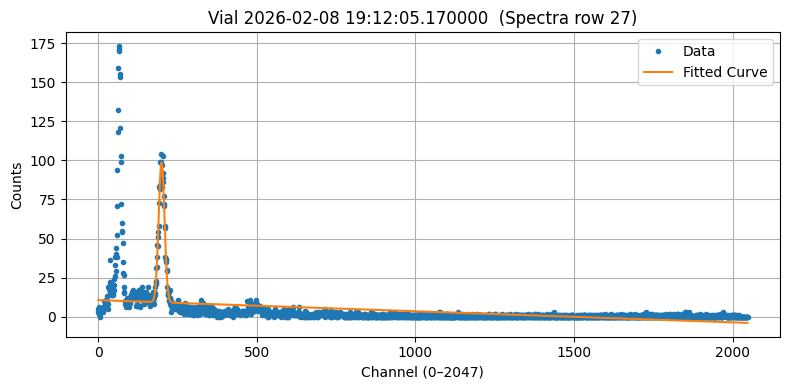

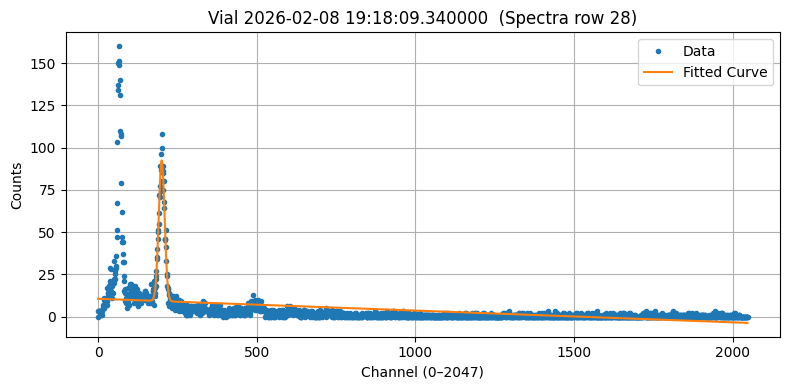

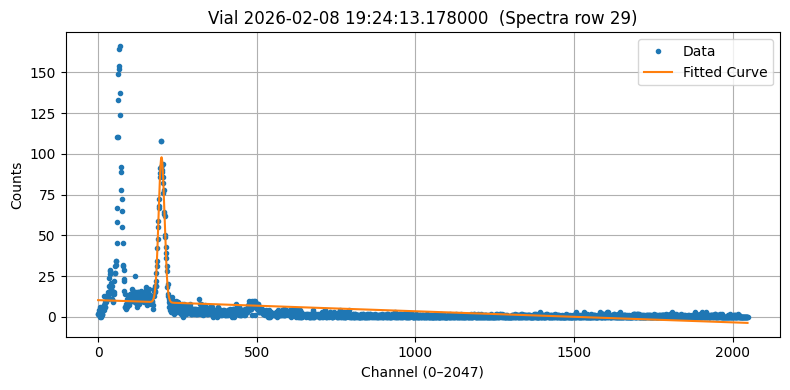

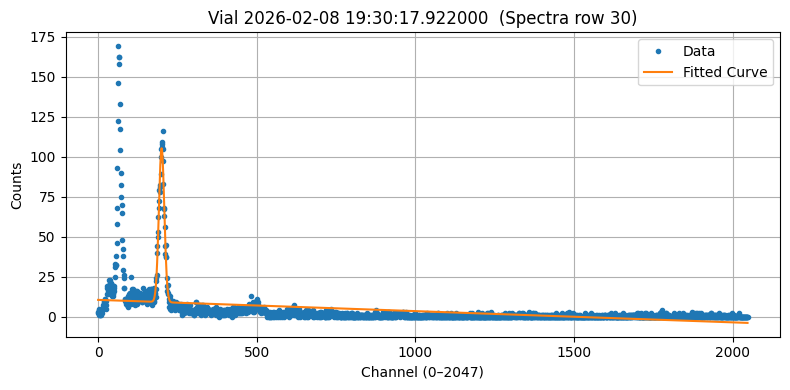

  Results saved to: /Users/pabloherrero/sabat/RaTagging/scope_data/hidex_data/Results_Analysis.xlsx
Processing: HidexAMG-Pablo_measurement_3-001-20260217-234347.xlsx


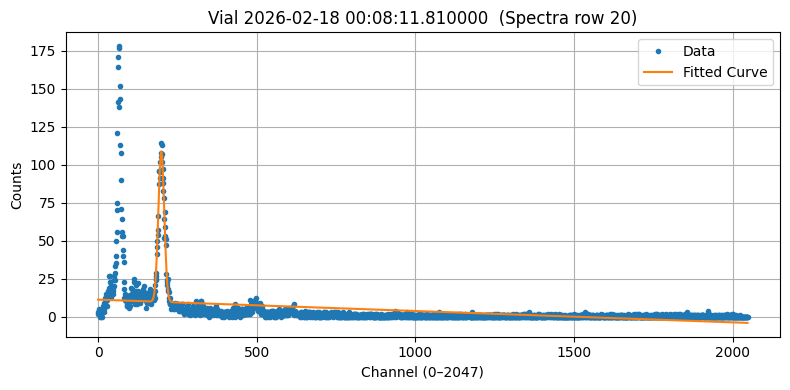

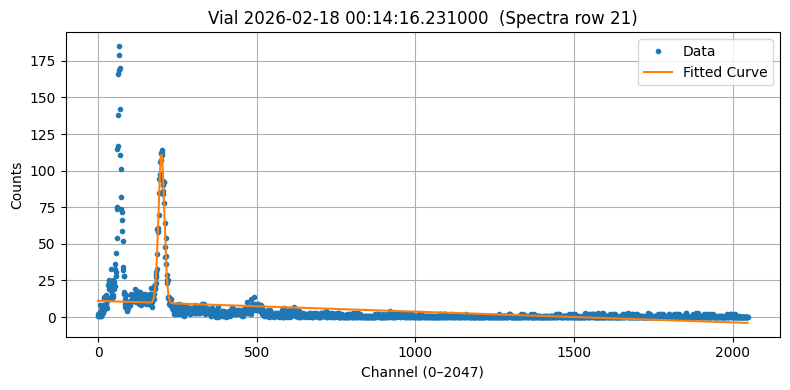

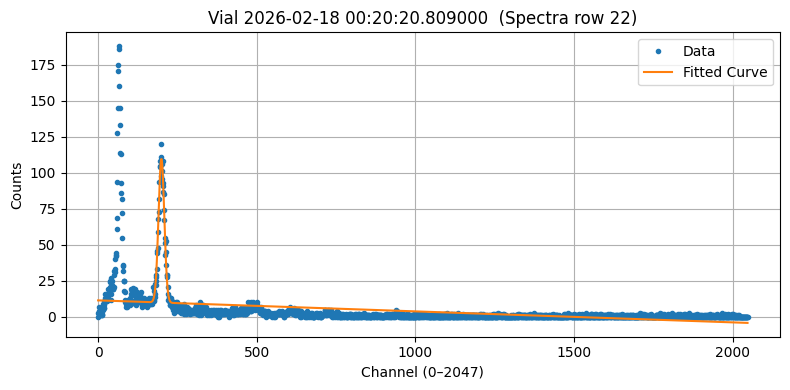

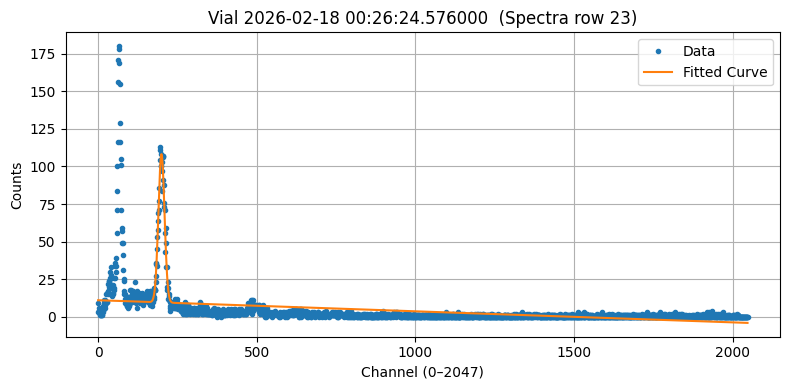

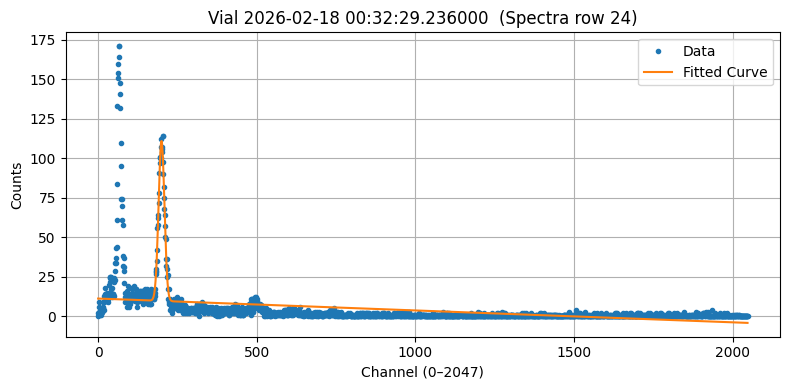

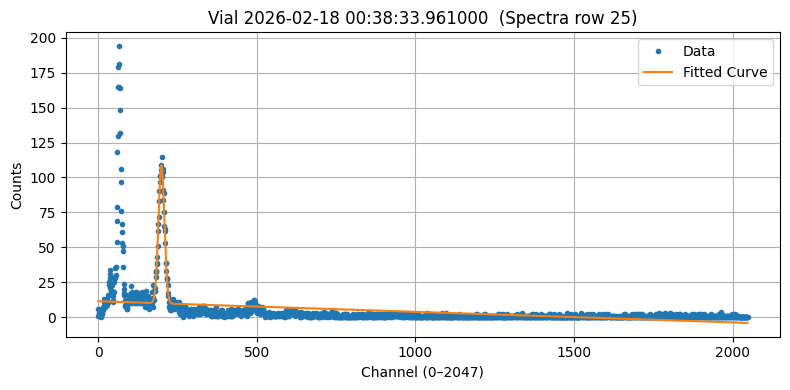

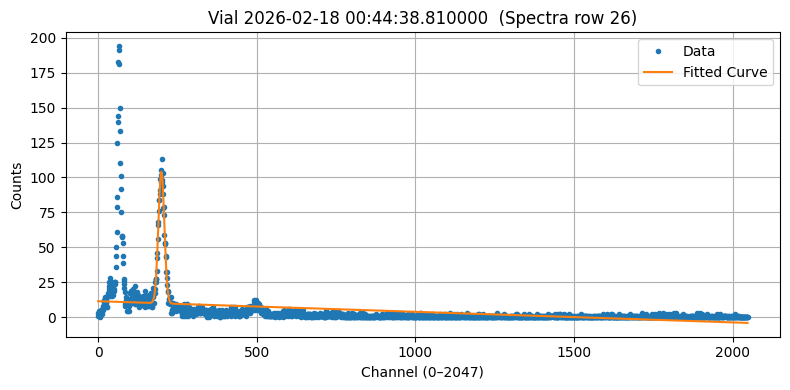

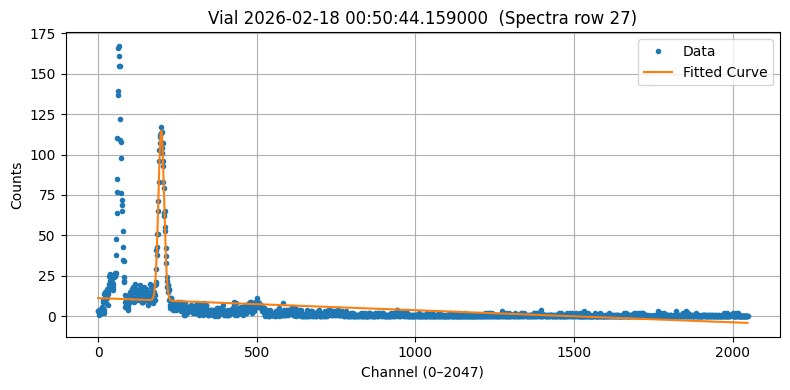

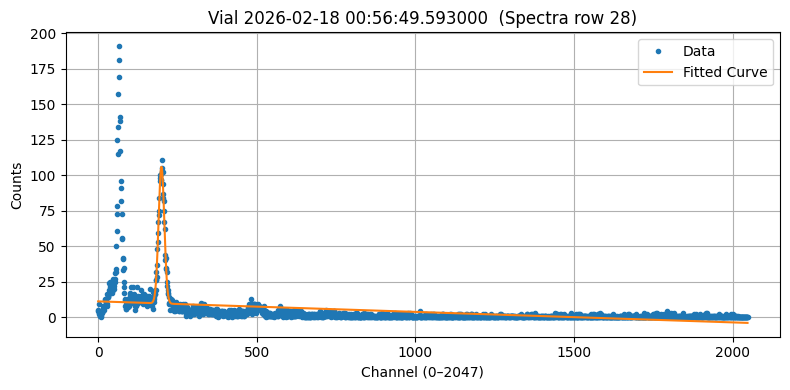

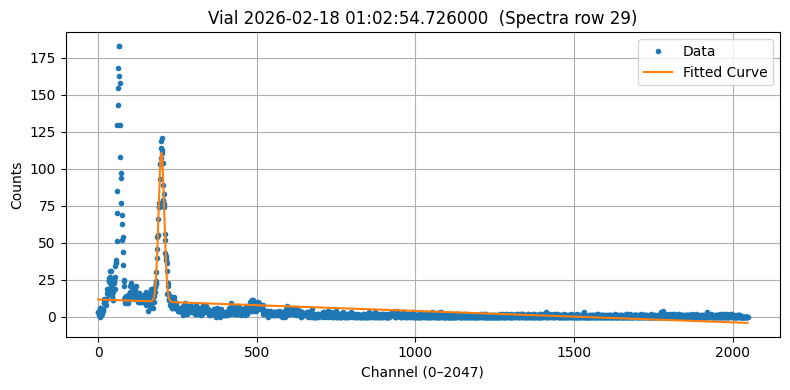

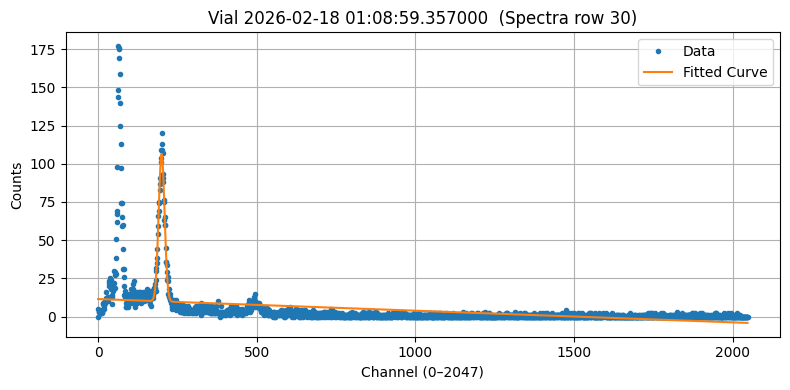

  Results saved to: /Users/pabloherrero/sabat/RaTagging/scope_data/hidex_data/Results_Analysis.xlsx


,ExcelRow,VialNumber,ParamC,ParamD,ParamE,A,Mu,Sigma,B,C,R_Square
0,20,2026-02-03 16:02:09.079,1,6,2021-12-21 14:49:03.356,93.569823,202.196353,8.935888,-0.006883,10.533094,0.466363
1,21,2026-02-03 16:08:13.181,1,6,2021-12-21 14:49:03.356,95.607027,202.602138,8.621938,-0.006869,10.533700,0.462860
2,22,2026-02-03 16:14:17.305,1,6,2021-12-21 14:49:03.356,92.768682,202.259978,9.036538,-0.006906,10.539782,0.476368
3,23,2026-02-03 16:20:21.600,1,6,2021-12-21 14:49:03.356,88.013851,202.608714,9.190320,-0.006765,10.353968,0.451723
4,24,2026-02-03 16:26:25.736,1,6,2021-12-21 14:49:03.356,91.328851,201.957970,8.625700,-0.006901,10.577983,0.453175


In [7]:

# ── Run the analysis ──────────────────────────────────────────────────────────
FOLDER_PATH = "/Users/pabloherrero/sabat/RaTagging/scope_data/hidex_data"

final_results = analyze_hidex_folder(FOLDER_PATH)
final_results.head()


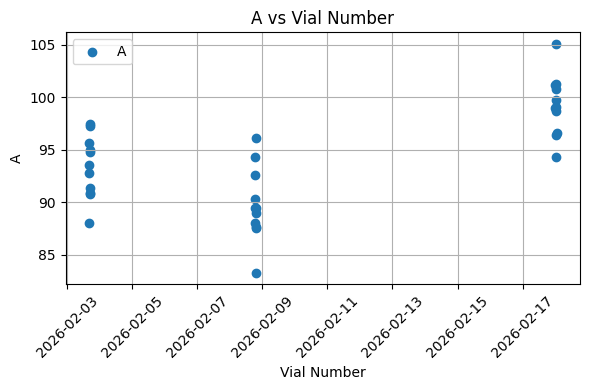

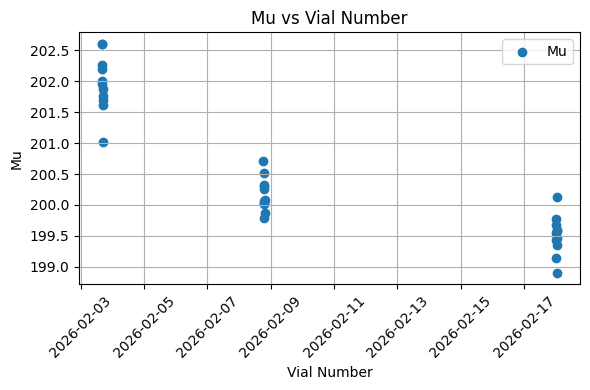

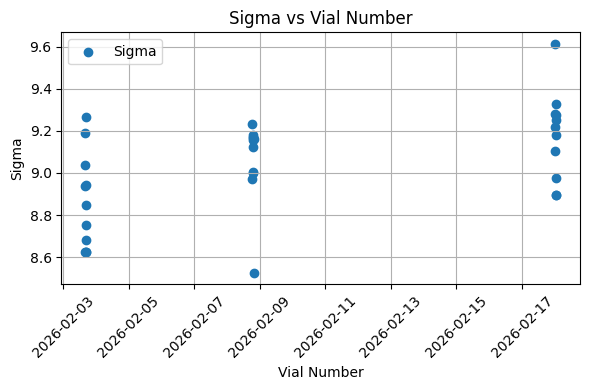

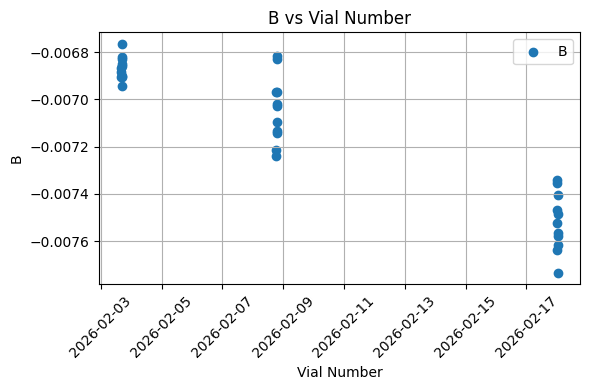

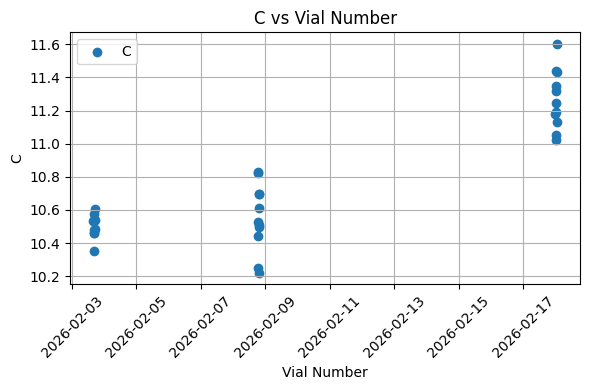

In [8]:
for col in ["A", "Mu", "Sigma", "B", "C"]:
    plt.figure(figsize=(6, 4))
    plt.scatter(final_results["VialNumber"], final_results[col], label=col)
    plt.xlabel("Vial Number")
    plt.xticks(rotation=45)
    plt.ylabel(col)
    plt.title(f"{col} vs Vial Number")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [9]:
final_results['VialNumber']

0    2026-02-03 16:02:09.079
1    2026-02-03 16:08:13.181
2    2026-02-03 16:14:17.305
3    2026-02-03 16:20:21.600
4    2026-02-03 16:26:25.736
5    2026-02-03 16:32:29.475
6    2026-02-03 16:38:33.603
7    2026-02-03 16:44:37.657
8    2026-02-03 16:50:41.506
9    2026-02-03 16:56:45.337
10   2026-02-03 17:02:49.486
11   2026-02-08 18:29:35.820
12   2026-02-08 18:35:39.502
13   2026-02-08 18:41:43.974
14   2026-02-08 18:47:48.637
15   2026-02-08 18:53:52.462
16   2026-02-08 18:59:56.348
17   2026-02-08 19:06:00.357
18   2026-02-08 19:12:05.170
19   2026-02-08 19:18:09.340
20   2026-02-08 19:24:13.178
21   2026-02-08 19:30:17.922
22   2026-02-18 00:08:11.810
23   2026-02-18 00:14:16.231
24   2026-02-18 00:20:20.809
25   2026-02-18 00:26:24.576
26   2026-02-18 00:32:29.236
27   2026-02-18 00:38:33.961
28   2026-02-18 00:44:38.810
29   2026-02-18 00:50:44.159
30   2026-02-18 00:56:49.593
31   2026-02-18 01:02:54.726
32   2026-02-18 01:08:59.357
Name: VialNumber, dtype: datetime64[ns]

In [20]:
final_results

,ExcelRow,VialNumber,ParamC,ParamD,ParamE,A,Mu,Sigma,B,C,R_Square,net_counts,net_counts_error
0,20,2026-02-03 16:02:09.079,1,6,2021-12-21 14:49:03.356,93.569823,202.196353,8.935888,-0.006883,10.533094,0.466363,2095.865706,296.400171
1,21,2026-02-03 16:08:13.181,1,6,2021-12-21 14:49:03.356,95.607027,202.602138,8.621938,-0.006869,10.533700,0.462860,2066.258460,292.213074
2,22,2026-02-03 16:14:17.305,1,6,2021-12-21 14:49:03.356,92.768682,202.259978,9.036538,-0.006906,10.539782,0.476368,2101.325857,297.172353
3,23,2026-02-03 16:20:21.600,1,6,2021-12-21 14:49:03.356,88.013851,202.608714,9.190320,-0.006765,10.353968,0.451723,2027.550069,286.738881
4,24,2026-02-03 16:26:25.736,1,6,2021-12-21 14:49:03.356,91.328851,201.957970,8.625700,-0.006901,10.577983,0.453175,1974.659743,279.259059
5,25,2026-02-03 16:32:29.475,1,6,2021-12-21 14:49:03.356,90.797729,202.008092,8.941264,-0.006819,10.462485,0.464329,2034.997359,287.792086
6,26,2026-02-03 16:38:33.603,1,6,2021-12-21 14:49:03.356,97.419662,201.761764,8.623258,-0.006858,10.479439,0.479089,2105.755363,297.798779
7,27,2026-02-03 16:44:37.657,1,6,2021-12-21 14:49:03.356,94.798805,201.695271,8.751475,-0.006827,10.459257,0.470306,2079.572412,294.095951
8,28,2026-02-03 16:50:41.506,1,6,2021-12-21 14:49:03.356,90.846323,201.610901,9.263430,-0.006905,10.539960,0.460841,2109.449487,298.321207
9,29,2026-02-03 16:56:45.337,1,6,2021-12-21 14:49:03.356,97.250491,201.883090,8.680175,-0.006852,10.482774,0.485123,2115.973551,299.243849


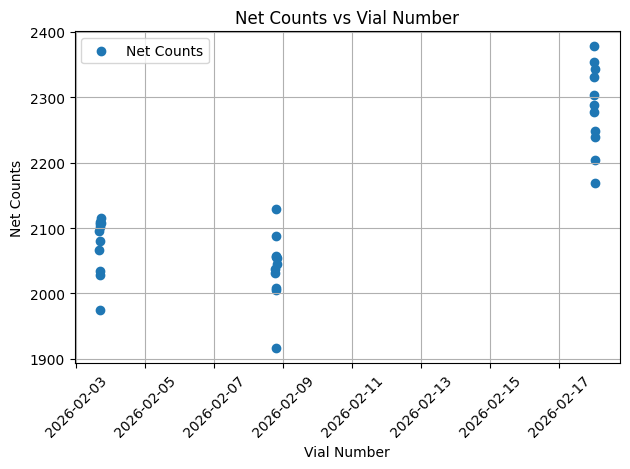

In [10]:

dft = 1.0   # Death factor
t_aq = 1.0   # Acquisition time in seconds (example value, adjust as needed)
final_results['net_counts'] = final_results['A'] * np.sqrt(2 * np.pi) * final_results['Sigma'] * dft / t_aq
final_results['net_counts_error'] = final_results['net_counts'] * np.sqrt((0.1)**2 + (0.1)**2)  # Example 10% error on A and Sigma
# i0, ifi = 11, 22
i0, ifi = 0, len(final_results)  # Plot all vials
plt.scatter(final_results["VialNumber"][i0:ifi], final_results['net_counts'][i0:ifi], label='Net Counts')
plt.gca().set(xlabel="Vial Number", ylabel="Net Counts", title="Net Counts vs Vial Number")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()

In [ ]:
import numpy as np
from scipy.optimize import curve_fit

# Decay constants based on half-lives (assuming time 't' is in SECONDS)
# Ra224 half-life = 3.6319 days
LAMBDA_RA = np.log(2) / (3.6319 * 24 * 3600)  # ~2.21e-6 s^-1
# Pb212 half-life = 10.64 hours 
LAMBDA_PB = np.log(2) / (10.64 / 24.0 * 3600)  # ~1.5635 days^-1

def bateman_count_rate(t: np.ndarray, n_ra_0: float, n_pb_0: float, e_ph: float = 1.0) -> np.ndarray:
    """
    Calculates the expected gamma count rate from Ra224 and Pb212 activities,
    with fixed decay constants for stability.
    
    Parameters:
    - t: time array in SECONDS.
    - n_ra_0: Initial number of Ra224 atoms (Free parameter).
    - n_pb_0: Initial number of Pb212 atoms (Free parameter).
    - e_ph: Gamma detection efficiency (default 1.0, can be scaled if known).
    """
    # Ra224 Activity
    activity_ra = LAMBDA_RA * n_ra_0 * np.exp(-LAMBDA_RA * t)
    
    # Pb212 Activity (Bateman equation)
    # The first term is the growth from Ra224, the second is decay of initial Pb212
    activity_pb = (LAMBDA_PB * n_ra_0 * (LAMBDA_RA / (LAMBDA_PB - LAMBDA_RA)) * (np.exp(-LAMBDA_RA * t) - np.exp(-LAMBDA_PB * t))) + \
                  (LAMBDA_PB * n_pb_0 * np.exp(-LAMBDA_PB * t))
    
    # Total count rate based on your branching ratios
    return e_ph * (0.041 * activity_ra + 0.436 * activity_pb)

def fit_initial_populations(times: np.ndarray, count_rates: np.ndarray, rate_errors: np.ndarray):
    """
    Fits the experimental count rates to extract initial Ra224 and Pb212 populations.
    """
    # Initial guesses: [n_ra_0, n_pb_0]
    # We estimate n_ra_0 assuming the first data point is mostly Ra224
    p0 = [np.max(count_rates) / (LAMBDA_RA * 0.041), 0.0]
    
    # Set bounds so atom counts cannot be negative
    bounds = (0, [np.inf, np.inf])
    
    popt, pcov = curve_fit(bateman_count_rate, times, count_rates,
                           p0=p0, sigma=rate_errors, 
                           absolute_sigma=True,bounds=bounds)
    
    # Extract results
    n_ra_0_fit, n_pb_0_fit = popt
    n_ra_0_err, n_pb_0_err = np.sqrt(np.diag(pcov))
    
    return {
        'n_ra_0': n_ra_0_fit,
        'n_ra_0_err': n_ra_0_err,
        'n_pb_0': n_pb_0_fit,
        'n_pb_0_err': n_pb_0_err
    }

In [12]:
def prepare_datetime(df):
    df['times'] = df['VialNumber'] - df['VialNumber'].min()
    df['times'] = df['times'].dt.total_seconds()
    return df

In [19]:
final_results

,ExcelRow,VialNumber,ParamC,ParamD,ParamE,A,Mu,Sigma,B,C,R_Square,net_counts,net_counts_error
0,20,2026-02-03 16:02:09.079,1,6,2021-12-21 14:49:03.356,93.569823,202.196353,8.935888,-0.006883,10.533094,0.466363,2095.865706,296.400171
1,21,2026-02-03 16:08:13.181,1,6,2021-12-21 14:49:03.356,95.607027,202.602138,8.621938,-0.006869,10.533700,0.462860,2066.258460,292.213074
2,22,2026-02-03 16:14:17.305,1,6,2021-12-21 14:49:03.356,92.768682,202.259978,9.036538,-0.006906,10.539782,0.476368,2101.325857,297.172353
3,23,2026-02-03 16:20:21.600,1,6,2021-12-21 14:49:03.356,88.013851,202.608714,9.190320,-0.006765,10.353968,0.451723,2027.550069,286.738881
4,24,2026-02-03 16:26:25.736,1,6,2021-12-21 14:49:03.356,91.328851,201.957970,8.625700,-0.006901,10.577983,0.453175,1974.659743,279.259059
5,25,2026-02-03 16:32:29.475,1,6,2021-12-21 14:49:03.356,90.797729,202.008092,8.941264,-0.006819,10.462485,0.464329,2034.997359,287.792086
6,26,2026-02-03 16:38:33.603,1,6,2021-12-21 14:49:03.356,97.419662,201.761764,8.623258,-0.006858,10.479439,0.479089,2105.755363,297.798779
7,27,2026-02-03 16:44:37.657,1,6,2021-12-21 14:49:03.356,94.798805,201.695271,8.751475,-0.006827,10.459257,0.470306,2079.572412,294.095951
8,28,2026-02-03 16:50:41.506,1,6,2021-12-21 14:49:03.356,90.846323,201.610901,9.263430,-0.006905,10.539960,0.460841,2109.449487,298.321207
9,29,2026-02-03 16:56:45.337,1,6,2021-12-21 14:49:03.356,97.250491,201.883090,8.680175,-0.006852,10.482774,0.485123,2115.973551,299.243849


In [13]:
m1 = final_results.iloc[:11]
m2 = final_results.iloc[11:22]
m3 = final_results.iloc[22:]

for m in [m1, m2, m3]:
    m = prepare_datetime(m)

/var/folders/tb/zxwsw51n6_g6gs5lnxdv2bcr0000gn/T/ipykernel_47478/1496141726.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['times'] = df['VialNumber'] - df['VialNumber'].min()
/var/folders/tb/zxwsw51n6_g6gs5lnxdv2bcr0000gn/T/ipykernel_47478/1496141726.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['times'] = df['times'].dt.total_seconds()
/var/folders/tb/zxwsw51n6_g6gs5lnxdv2bcr0000gn/T/ipykernel_47478/1496141726.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice

[None]

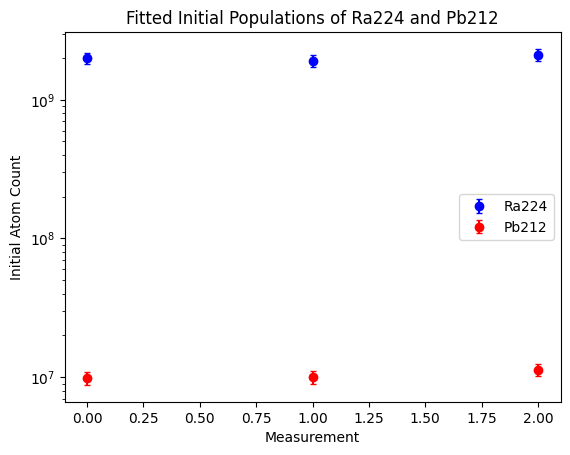

In [15]:
act1 = fit_initial_populations(times = m1['times'], count_rates = m1['net_counts'], rate_errors = m1['net_counts_error'])
act2 = fit_initial_populations(times = m2['times'], count_rates = m2['net_counts'], rate_errors = m2['net_counts_error'])
act3 = fit_initial_populations(times = m3['times'], count_rates = m3['net_counts'], rate_errors = m3['net_counts_error'])

acts_ra = [a['n_ra_0'] for a in [act1, act2, act3]]
acts_ra_err = [a['n_ra_0_err'] for a in [act1, act2, act3]]
acts_pb = [a['n_pb_0'] for a in [act1, act2, act3]]
acts_pb_err = [a['n_pb_0_err'] for a in [act1, act2, act3]]


plt.errorbar(range(len(acts_ra)), acts_ra, yerr=acts_ra_err, fmt='o', color='b', capsize=2, label=f'Ra224')
plt.errorbar(range(len(acts_pb)), acts_pb, yerr=acts_pb_err, fmt='o', color='r', capsize=2, label=f'Pb212')
plt.legend()
plt.gca().set(xlabel="Measurement", ylabel="Initial Atom Count", title="Fitted Initial Populations of Ra224 and Pb212")
plt.gca().set(yscale='log')

In [18]:
for a in acts_ra + acts_pb:
    print(f"{a:.2e}")

1.99e+09
1.92e+09
2.11e+09
9.89e+06
9.96e+06
1.14e+07


In [16]:
acts_ra[0] / acts_pb[0]

np.float64(201.64649673189257)

In [ ]:
def backcalculate_accumulation(n_ra_fit: float, n_pb_fit: float, 
                               delay_minutes: float, acc_s: float) -> dict:
    """
    Back-calculates atom populations at the end of the accumulation phase, 
    and determines the theoretical maximum source capacity.
    """
    delay_s = delay_minutes * 60
    
    # 1. Back-calculate Ra atoms at the moment accumulation ended
    n_ra_acc = n_ra_fit * np.exp(LAMBDA_RA * delay_s)
    
    # 2. Back-calculate Pb atoms at the moment accumulation ended
    # First, calculate how much Pb was *created* by Ra during the delay
    pb_from_ra_during_delay = n_ra_acc * (LAMBDA_RA / (LAMBDA_PB - LAMBDA_RA)) * \
                              (np.exp(-LAMBDA_RA * delay_s) - np.exp(-LAMBDA_PB * delay_s))
    
    # Subtract that created Pb, then un-decay the remainder to find the original Pb
    n_pb_acc = (n_pb_fit - pb_from_ra_during_delay) * np.exp(LAMBDA_PB * delay_s)
    
    # 3. Calculate Maximum Theoretical Ra Capacity (Saturation limit: R/lambda)
    # N_acc = Max * (1 - exp(-lambda * t_acc))
    max_ra_capacity = n_ra_acc / (1 - np.exp(-LAMBDA_RA * acc_s))
    
    return {
        'n_ra_end_acc': n_ra_acc,
        'n_pb_end_acc': n_pb_acc,
        'ratio_ra_to_pb_end_acc': n_ra_acc / max(n_pb_acc, 1.0),
        'max_ra_capacity': max_ra_capacity,
        'saturation_percentage': (n_ra_acc / max_ra_capacity) * 100
    }


In [ ]:
backcalculate_accumulation(n_ra_fit=acts_ra[0], n_pb_fit=acts_pb[0], delay_minutes=30, acc_s=7*24*3600)

{'n_ra_end_acc': np.float64(2001817999.881955),
 'n_pb_end_acc': np.float64(9567154.783537077),
 'ratio_ra_to_pb_end_acc': np.float64(209.23859236882356),
 'max_ra_capacity': np.float64(2715834772.3480115),
 'saturation_percentage': np.float64(73.70912325977976)}